In [2]:
import numpy as np
from matplotlib import pyplot as plt
from Thermography_tools import *
from matplotlib.ticker import MultipleLocator


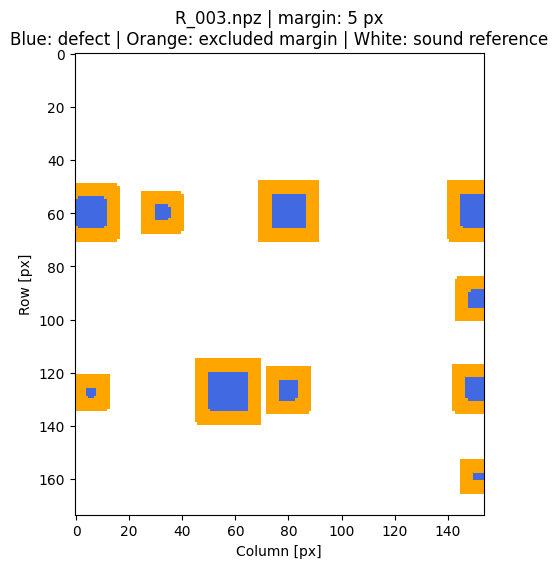

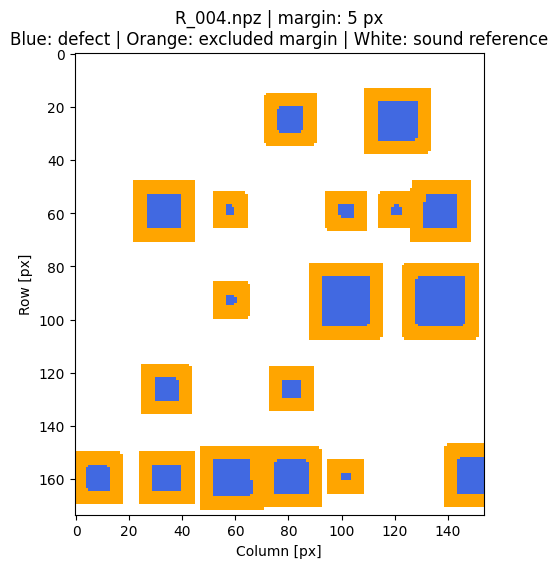

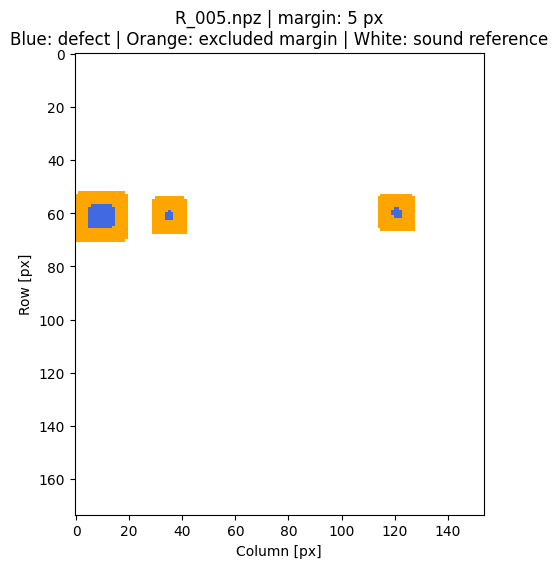

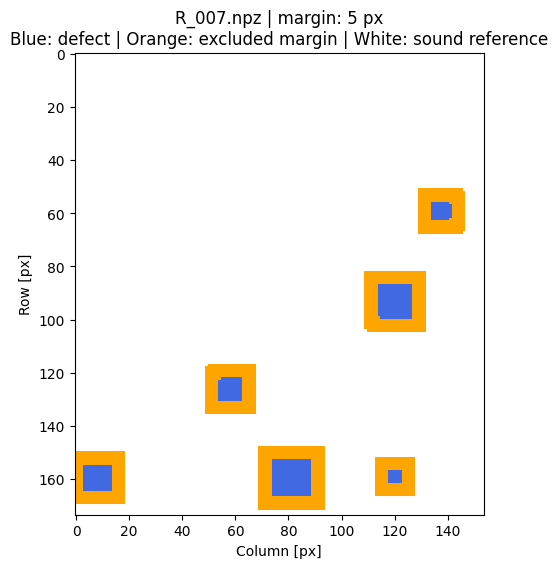

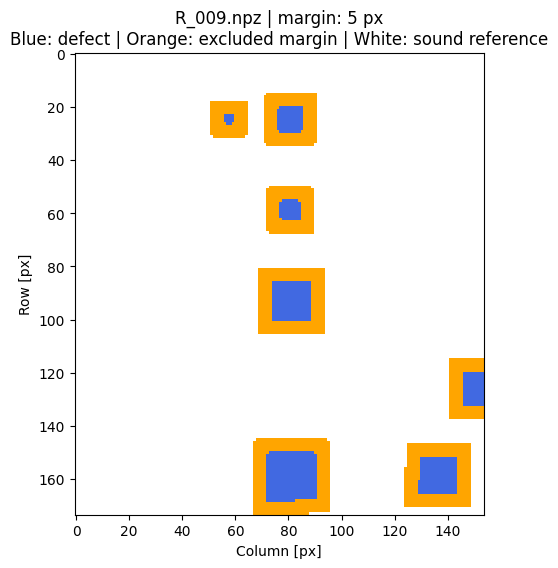

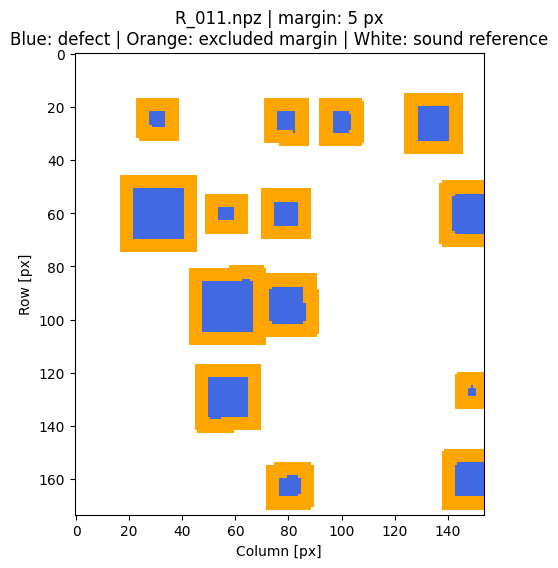

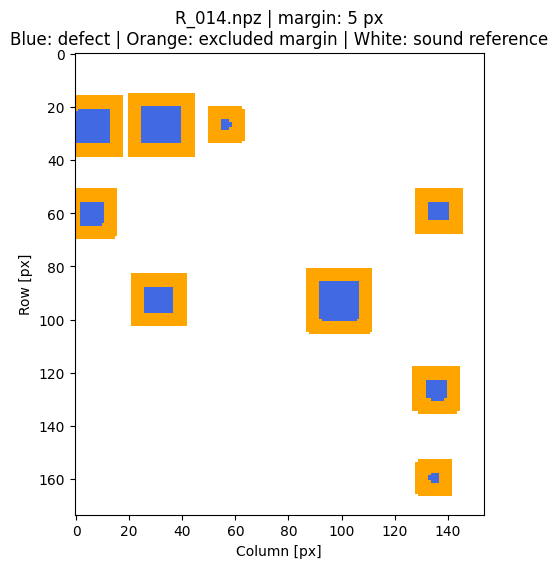

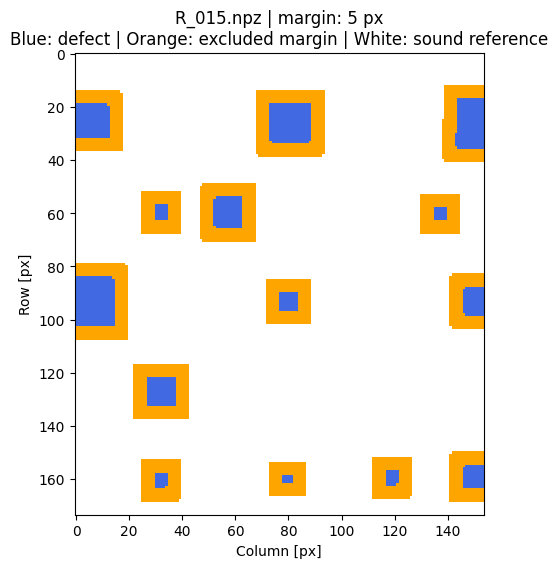

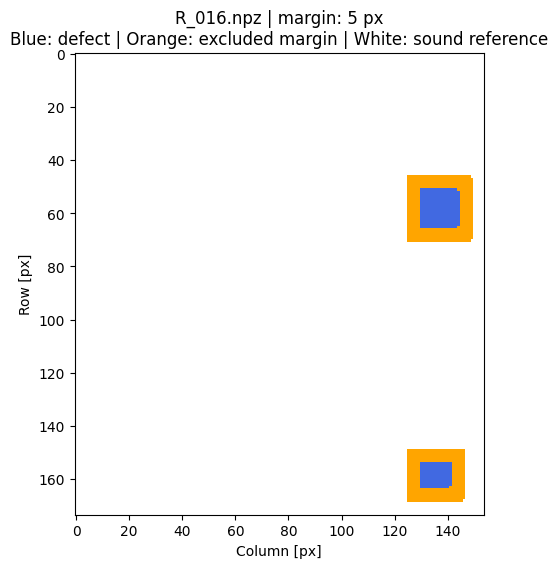

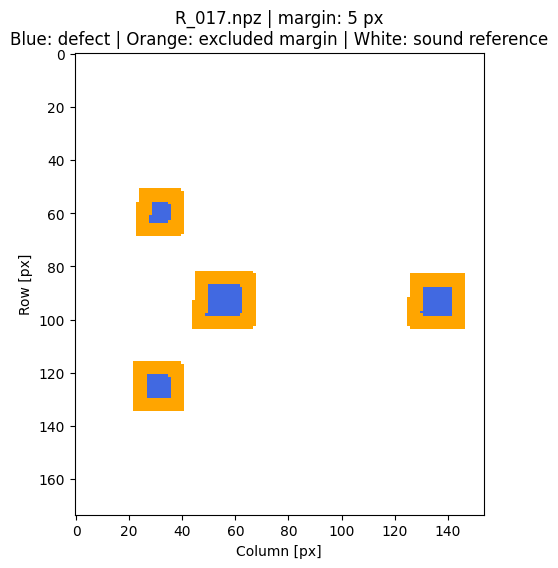

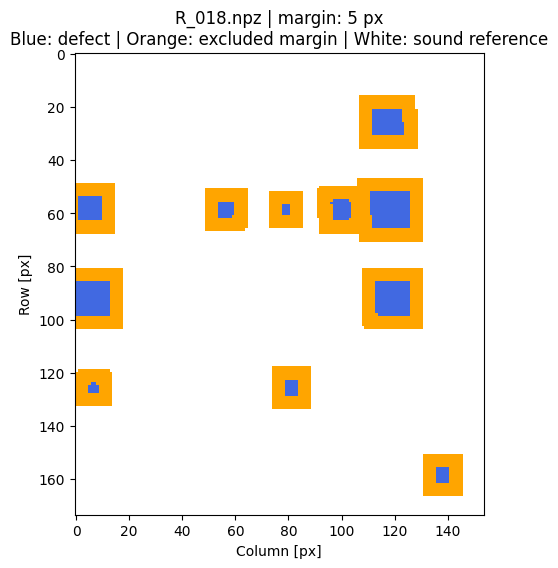

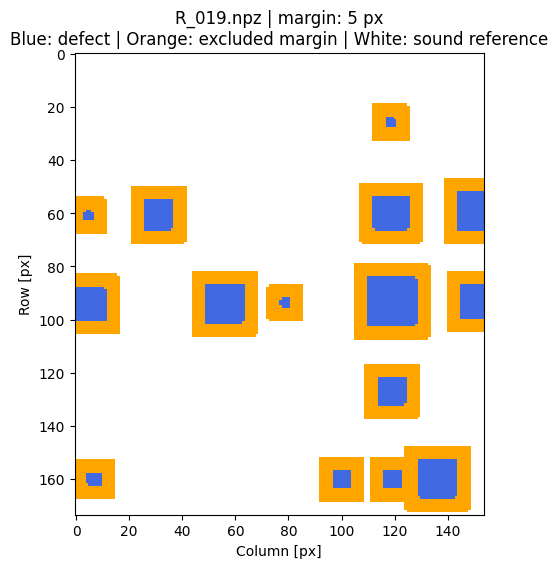

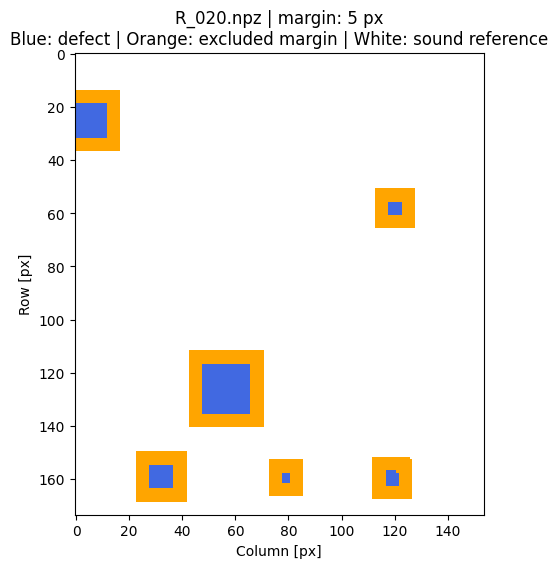

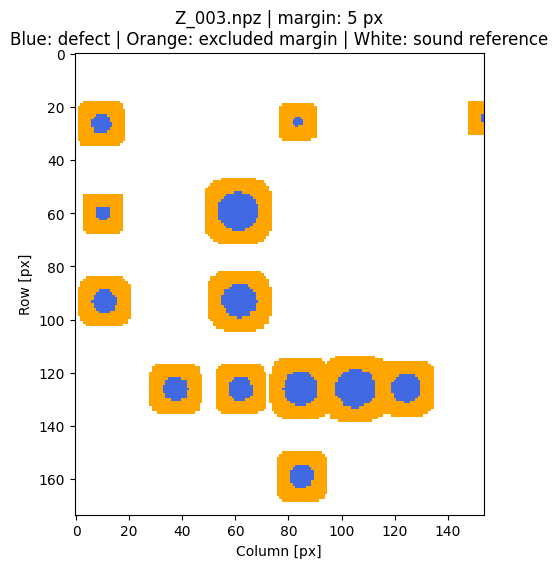

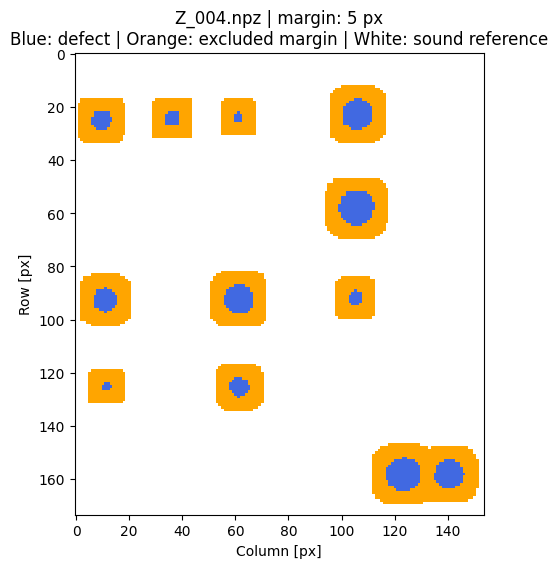

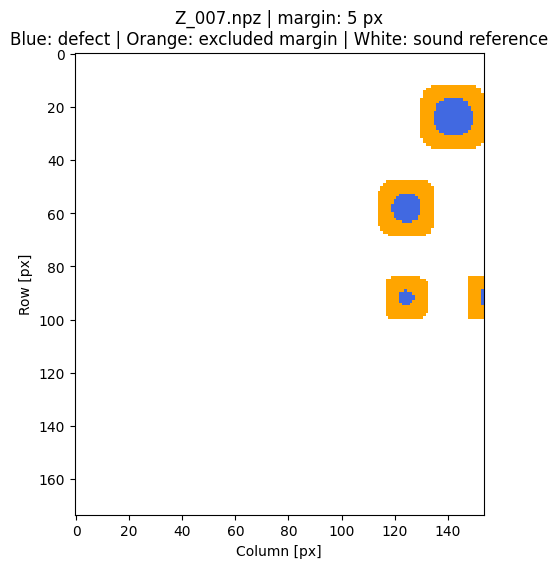

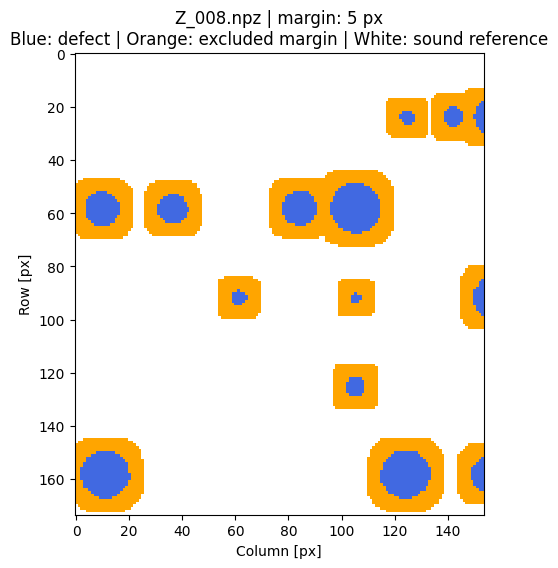

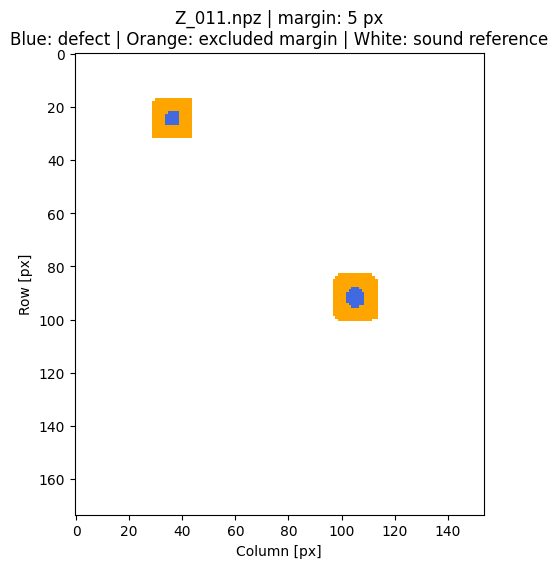

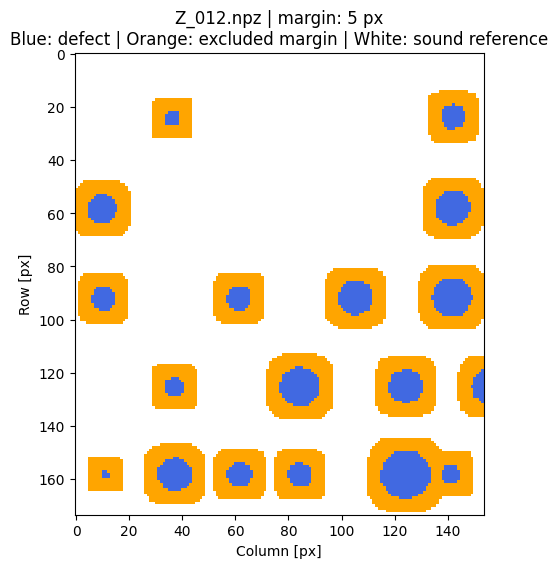

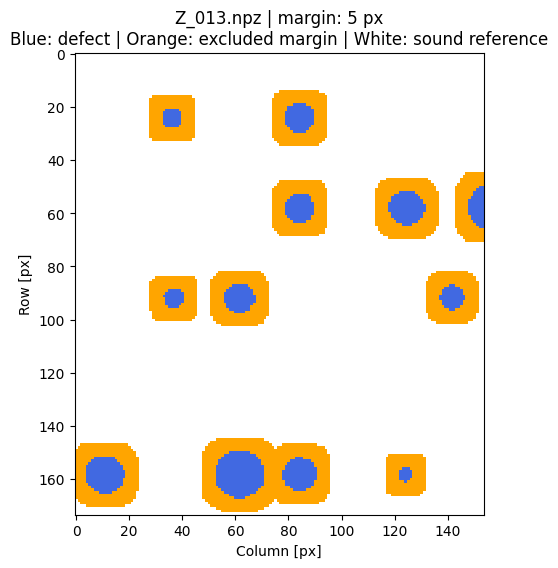

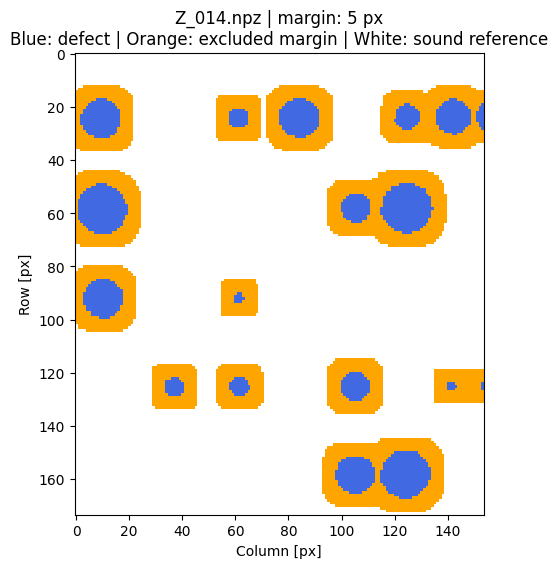

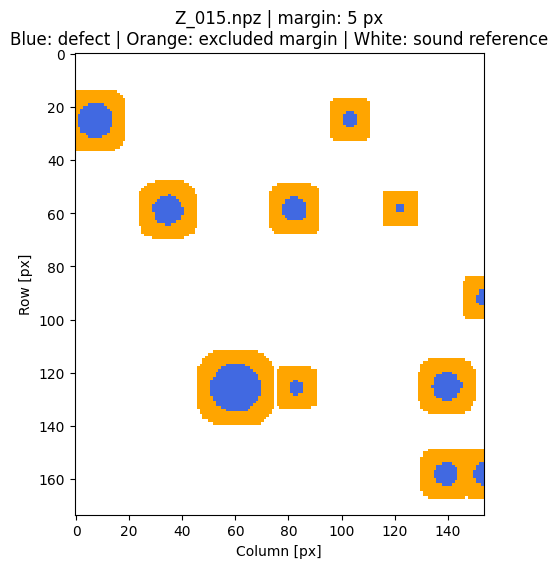

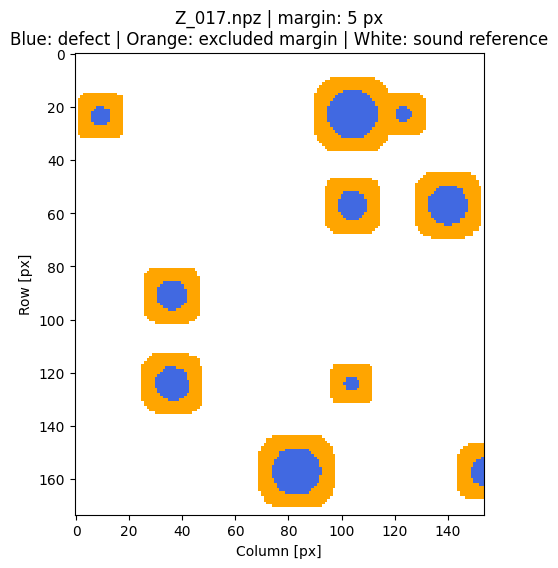

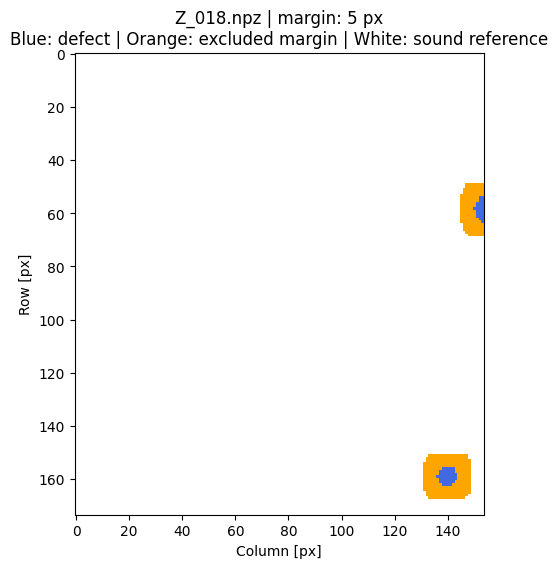

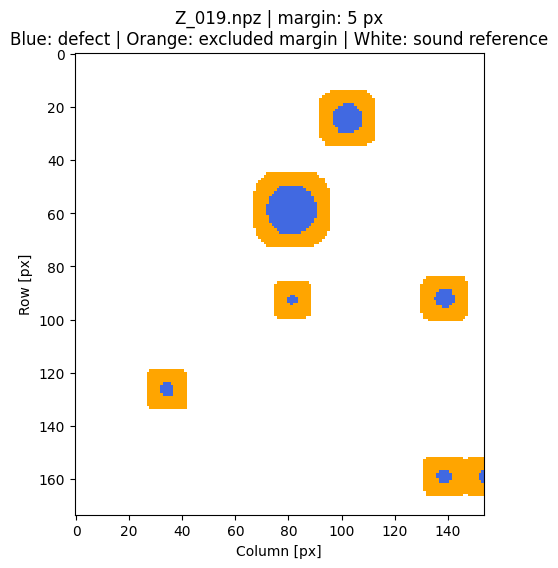

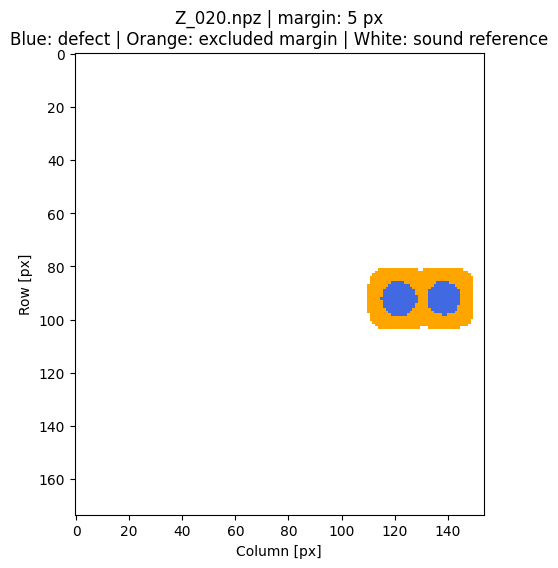

In [64]:
sound_mask=create_sound_masks('/home/jaworskj/projects/thermal_B_scan/open_source_dataset/training',5)

In [65]:
sound_phases,frequencies=calculate_sound_phases('/home/jaworskj/projects/thermal_B_scan/open_source_dataset/training',sound_mask,10)

In [66]:
sound_phase=summarize_phases(sound_phases)


In [67]:
from pathlib import Path

import numpy as np
from tqdm.auto import tqdm


def optimize_phase_threshold_iou(train_path, sound_mean):
    fps = 10
    thresholds = np.linspace(-1.5, -0.001, 100)

    minimum_contrasts = {}
    masks = {}

    # Calculate PPT once per experiment.
    for path in tqdm(
        sorted(Path(train_path).glob("*.npz")),
        desc="Calculating phase contrast",
    ):
        with np.load(path) as sample:
            _, phase, frequencies = PPT(sample["data"], fps)
            masks[path.name] = sample["mask"] > 0

        frequencies = np.asarray(frequencies)
        keep = (frequencies > 0) & (frequencies < fps / 2)

        contrast = np.angle(np.exp(
            1j * (
                phase[keep]
                - np.asarray(sound_mean)[keep, None, None]
            )
        ))

        minimum_contrasts[path.name] = contrast.min(axis=0)

    history = []

    for threshold in tqdm(thresholds, desc="Optimizing IoU"):
        per_experiment = {}

        for filename, minimum in minimum_contrasts.items():
            prediction = minimum < threshold
            gt = masks[filename]

            intersection = np.count_nonzero(prediction & gt)
            union = np.count_nonzero(prediction | gt)

            per_experiment[filename] = (
                intersection / union if union else 1.0
            )

        history.append({
            "threshold": float(threshold),
            "mean_iou": float(np.mean(list(per_experiment.values()))),
            "per_experiment": per_experiment,
        })

    best = max(history, key=lambda result: result["mean_iou"])

    best_masks = {
        filename: minimum < best["threshold"]
        for filename, minimum in minimum_contrasts.items()
    }

    print(f"\nBest threshold: {best['threshold']:.6f} rad")
    print(f"Mean training IoU: {best['mean_iou']:.4f}")

    for filename, iou in best["per_experiment"].items():
        print(f"{filename}: IoU = {iou:.4f}")

    return best["threshold"], best_masks, history

In [68]:
best_threshold, predicted_masks, iou_history = optimize_phase_threshold_iou(
    '/home/jaworskj/projects/thermal_B_scan/open_source_dataset/training',
    sound_phase["mean"],
)

Calculating phase contrast:   0%|          | 0/26 [00:00<?, ?it/s]

Optimizing IoU:   0%|          | 0/100 [00:00<?, ?it/s]


Best threshold: -0.212980 rad
Mean training IoU: 0.4573
R_003.npz: IoU = 0.4574
R_004.npz: IoU = 0.5613
R_005.npz: IoU = 0.0000
R_007.npz: IoU = 0.4745
R_009.npz: IoU = 0.6719
R_011.npz: IoU = 0.3843
R_014.npz: IoU = 0.3468
R_015.npz: IoU = 0.7109
R_016.npz: IoU = 0.7995
R_017.npz: IoU = 0.3341
R_018.npz: IoU = 0.0000
R_019.npz: IoU = 0.5471
R_020.npz: IoU = 0.6344
Z_003.npz: IoU = 0.3991
Z_004.npz: IoU = 0.5832
Z_007.npz: IoU = 0.7672
Z_008.npz: IoU = 0.5672
Z_011.npz: IoU = 0.0649
Z_012.npz: IoU = 0.3860
Z_013.npz: IoU = 0.4997
Z_014.npz: IoU = 0.6524
Z_015.npz: IoU = 0.0334
Z_017.npz: IoU = 0.5830
Z_018.npz: IoU = 0.5556
Z_019.npz: IoU = 0.6062
Z_020.npz: IoU = 0.2693


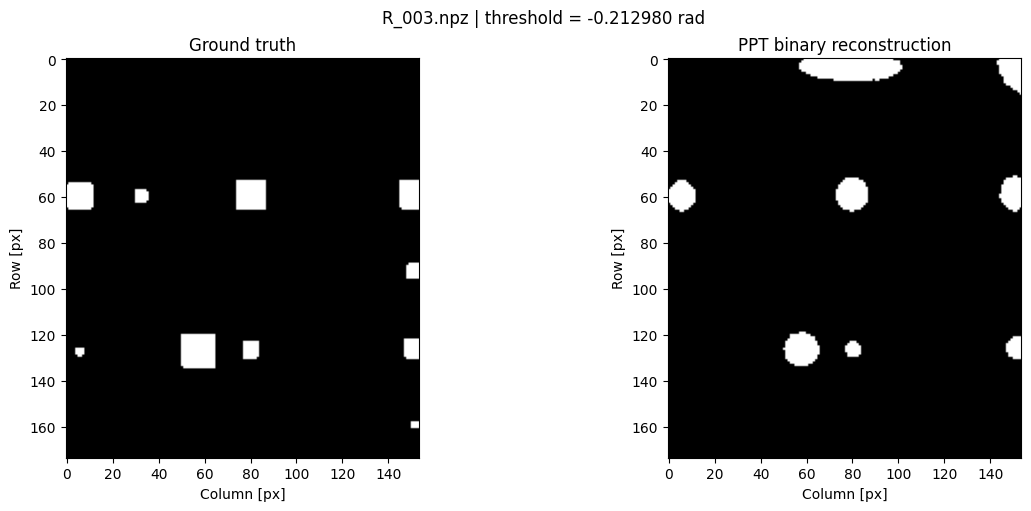

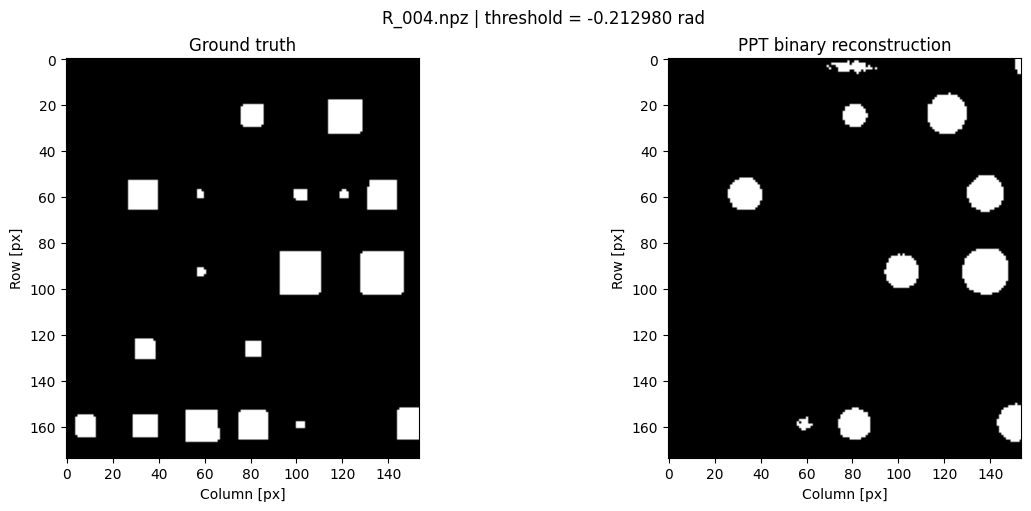

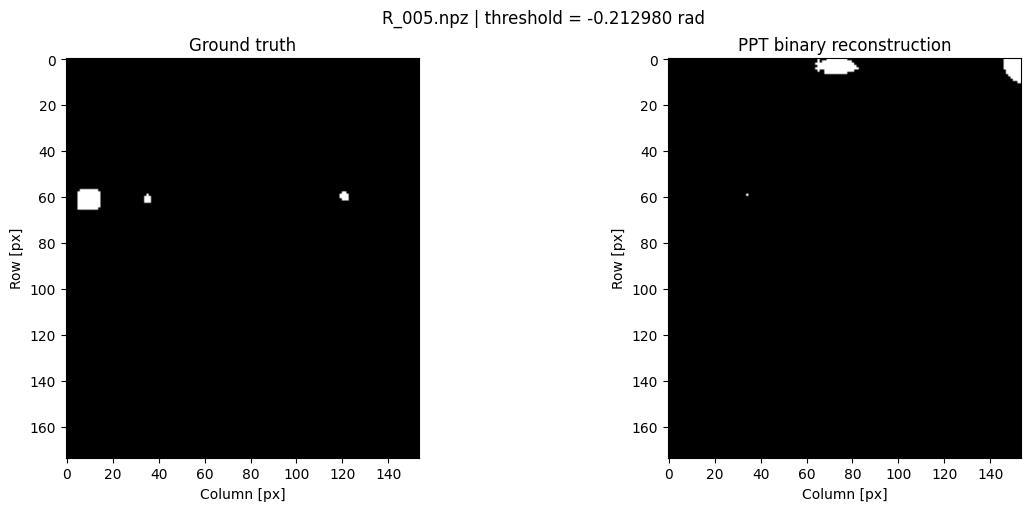

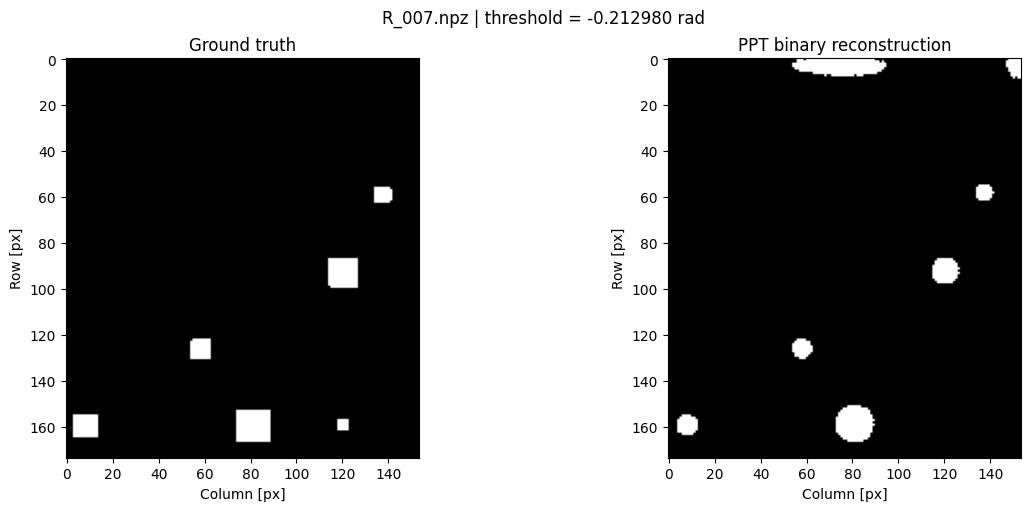

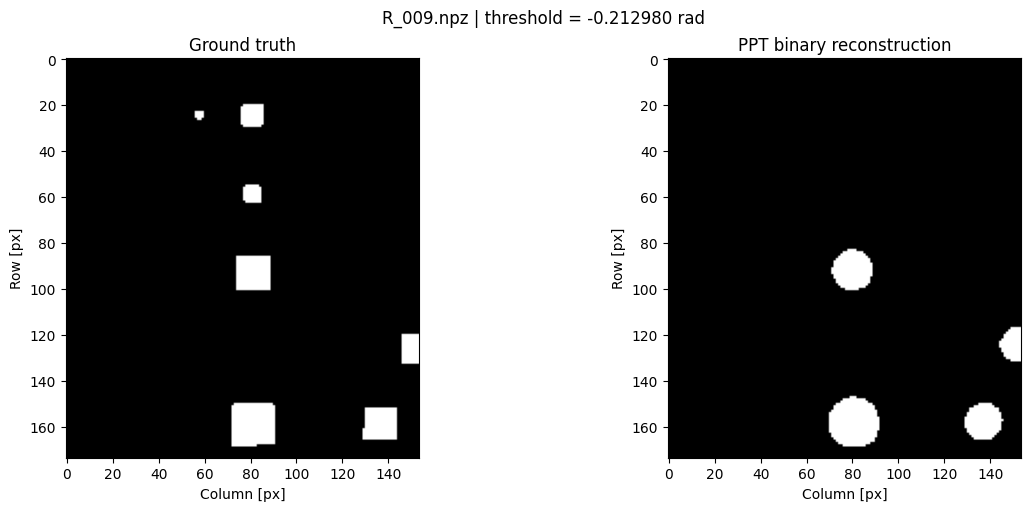

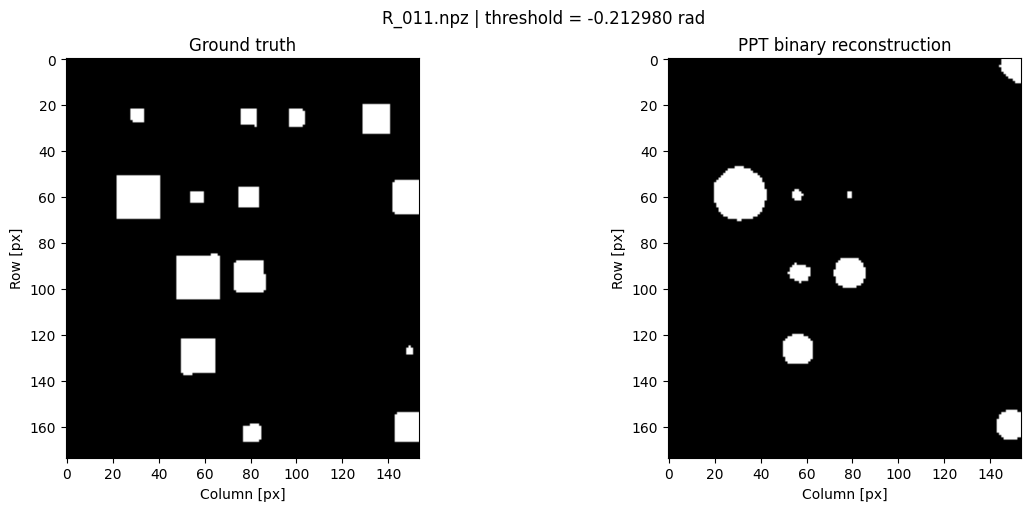

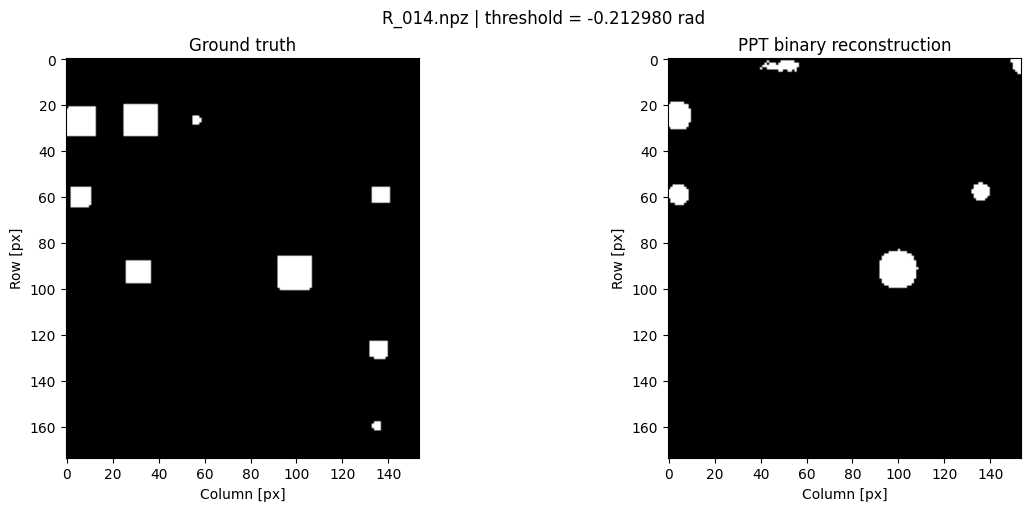

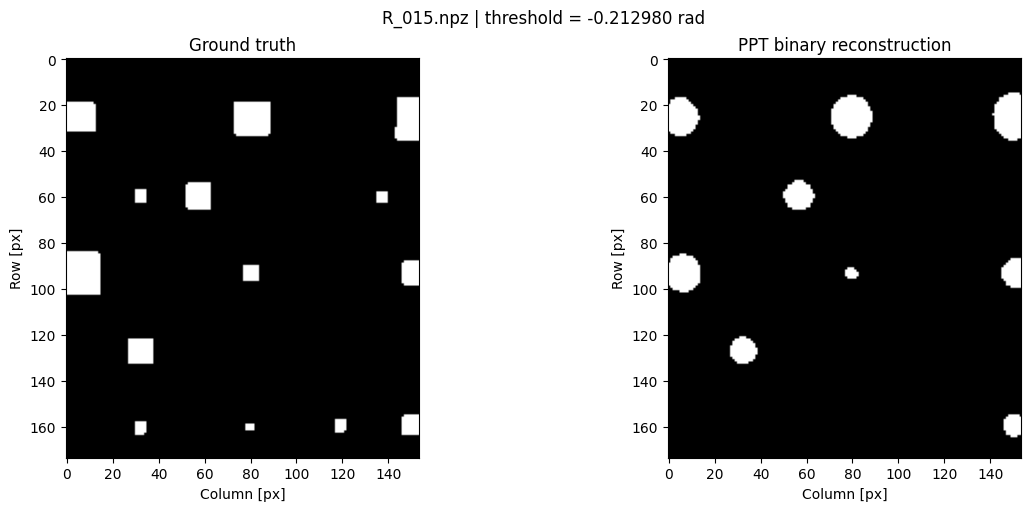

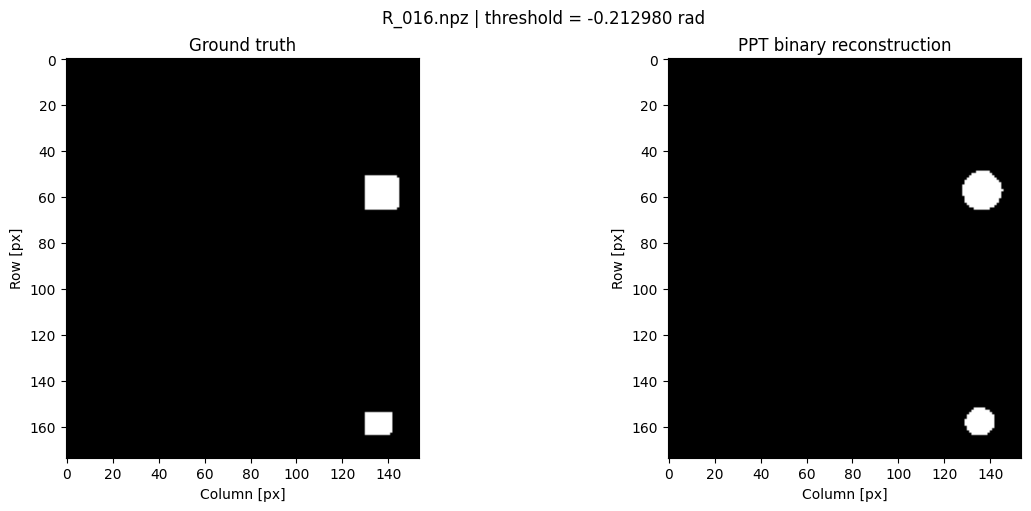

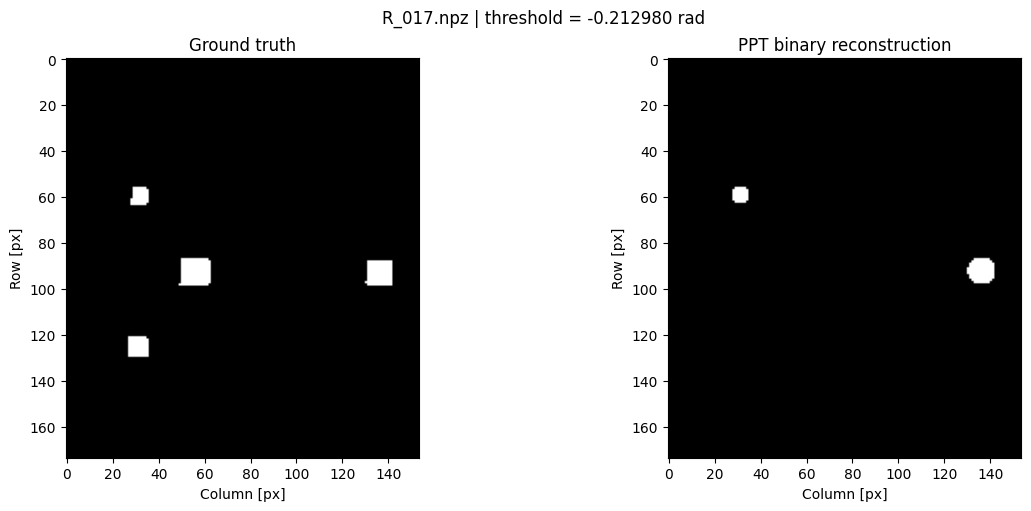

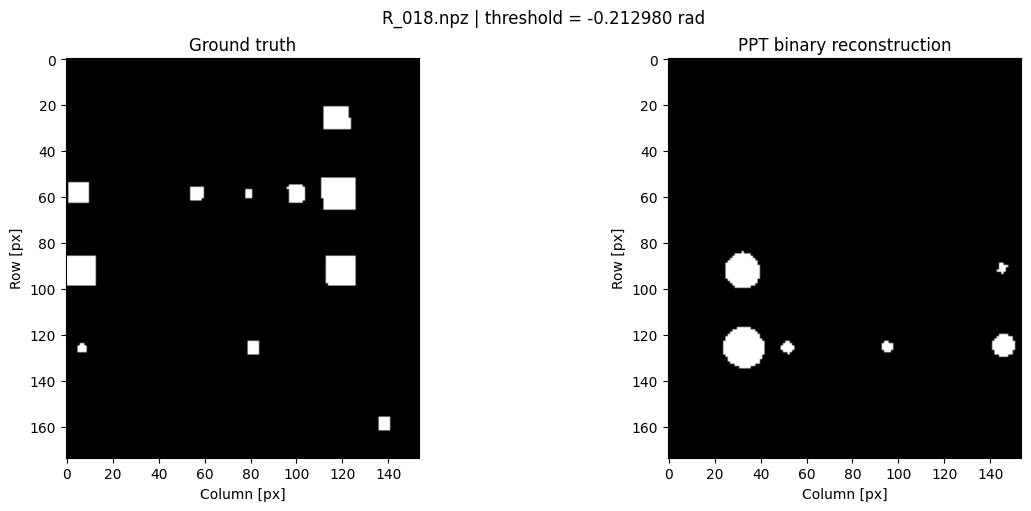

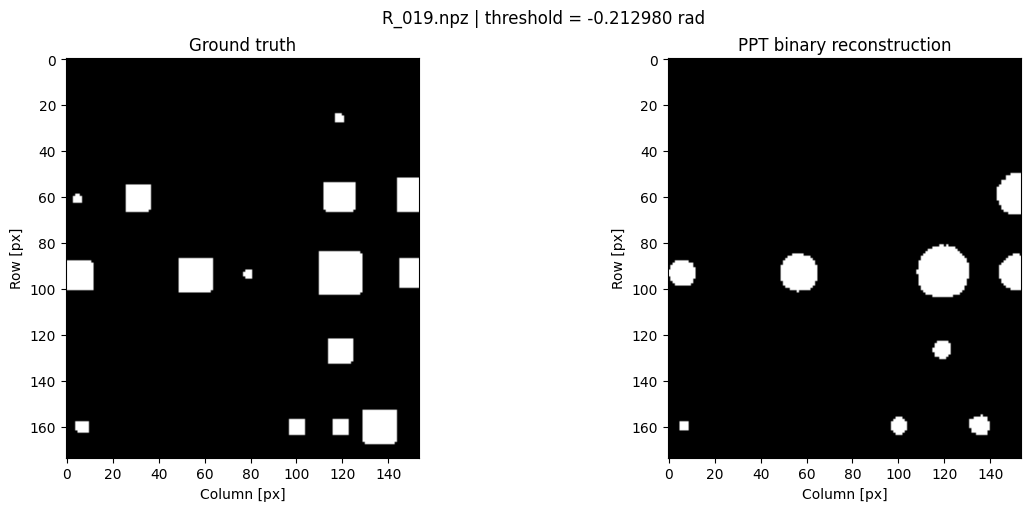

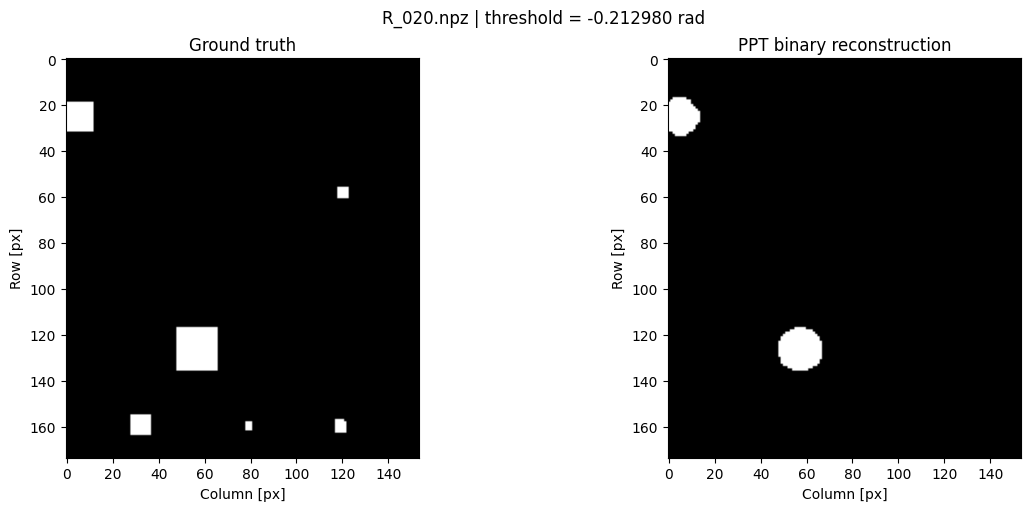

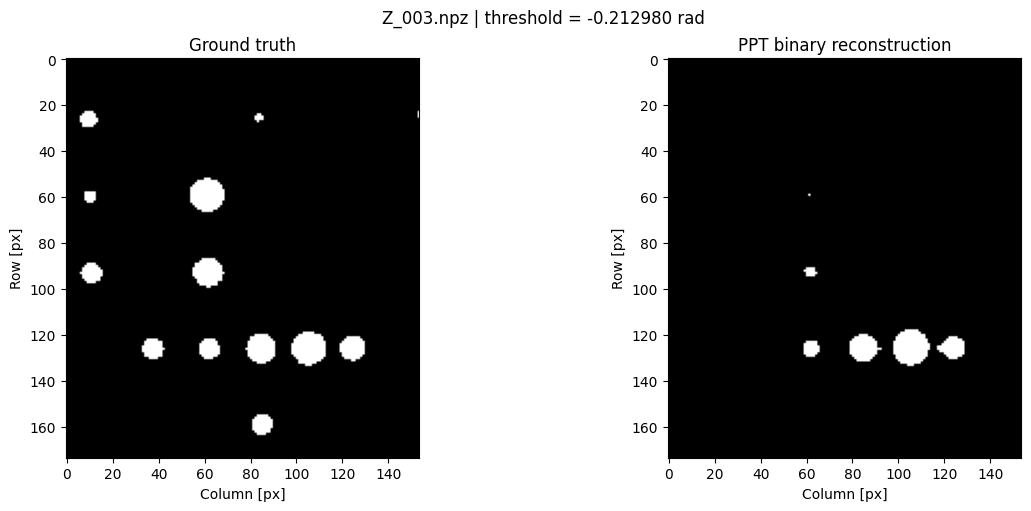

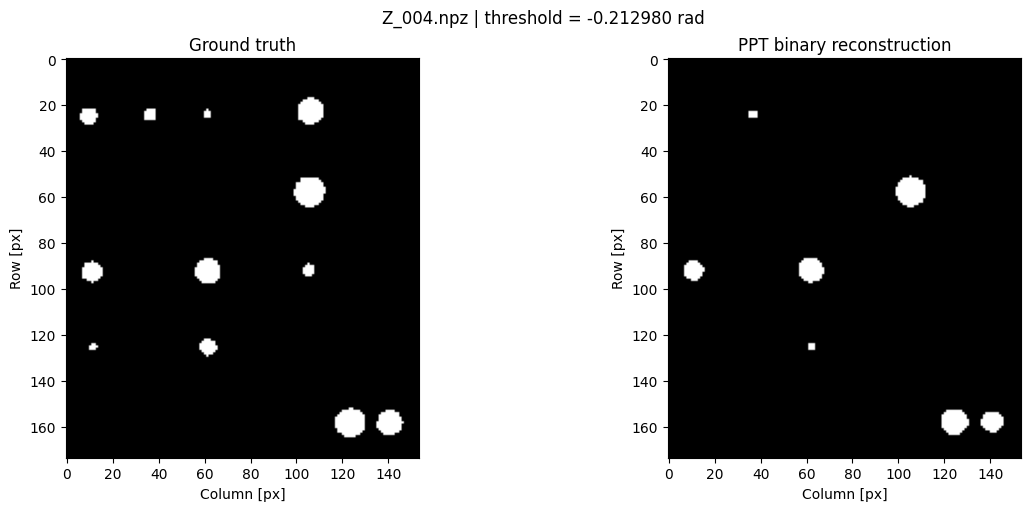

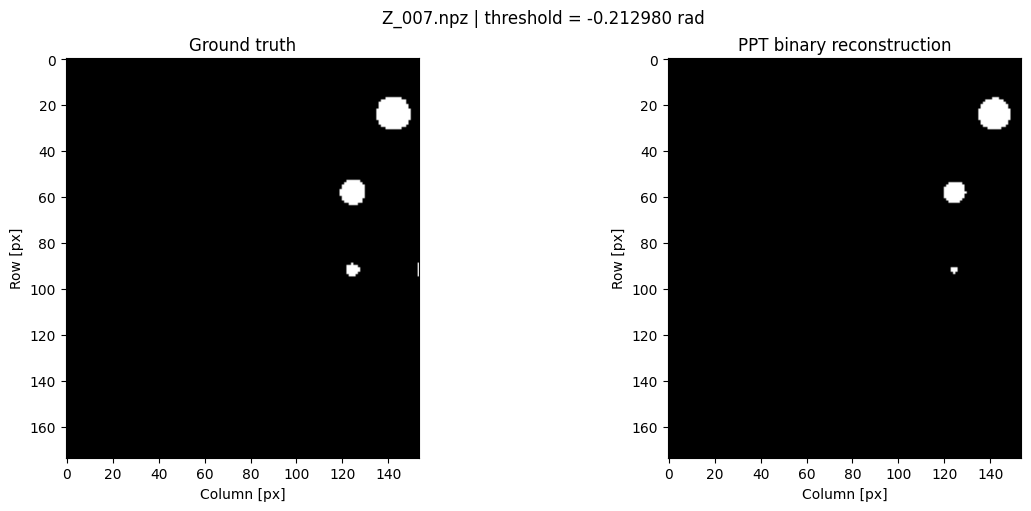

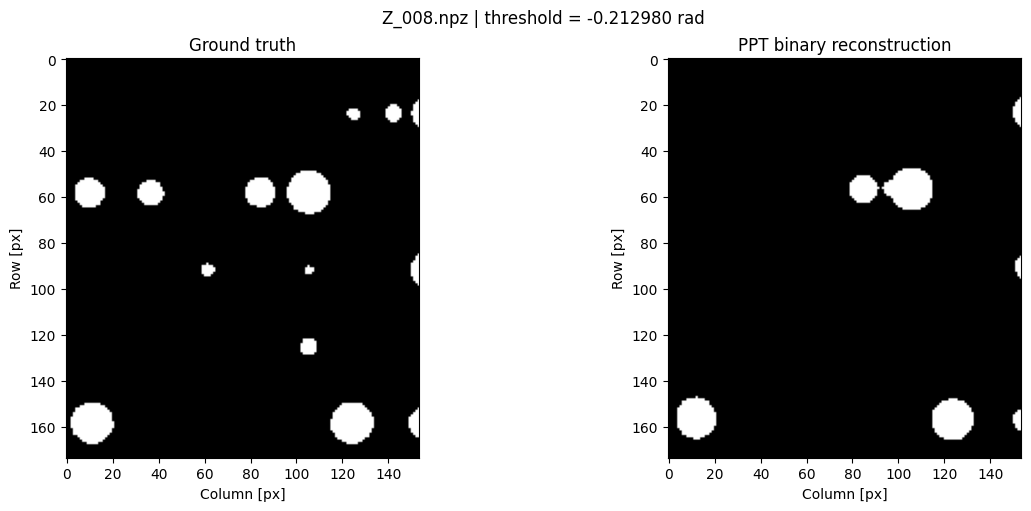

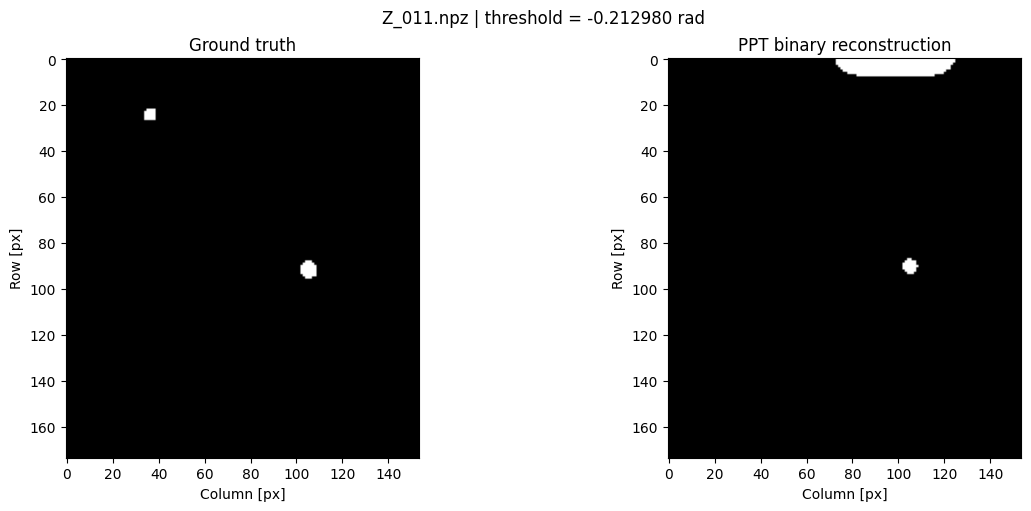

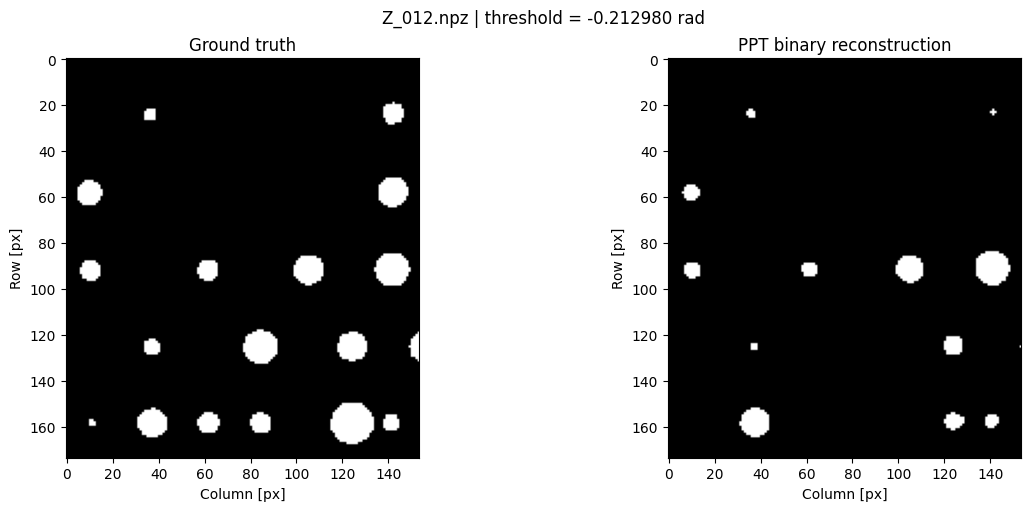

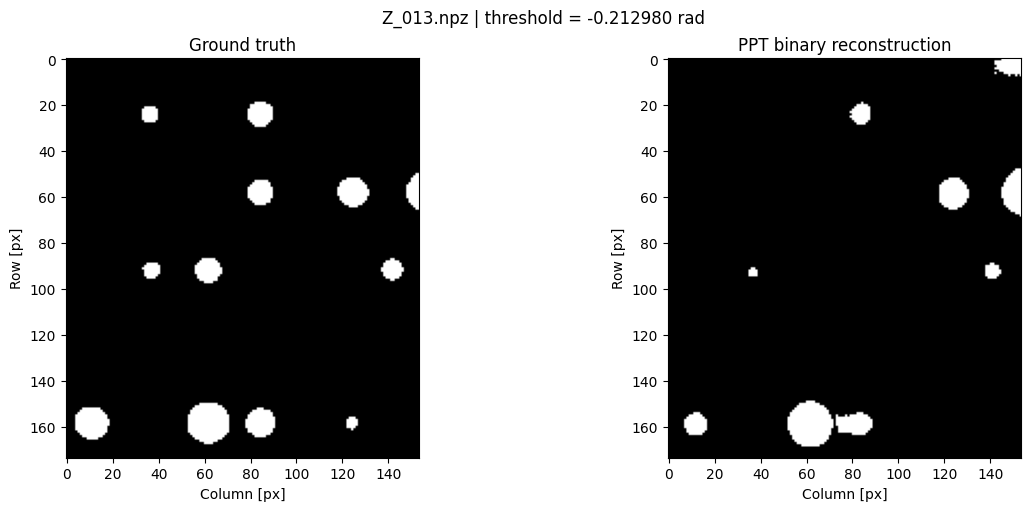

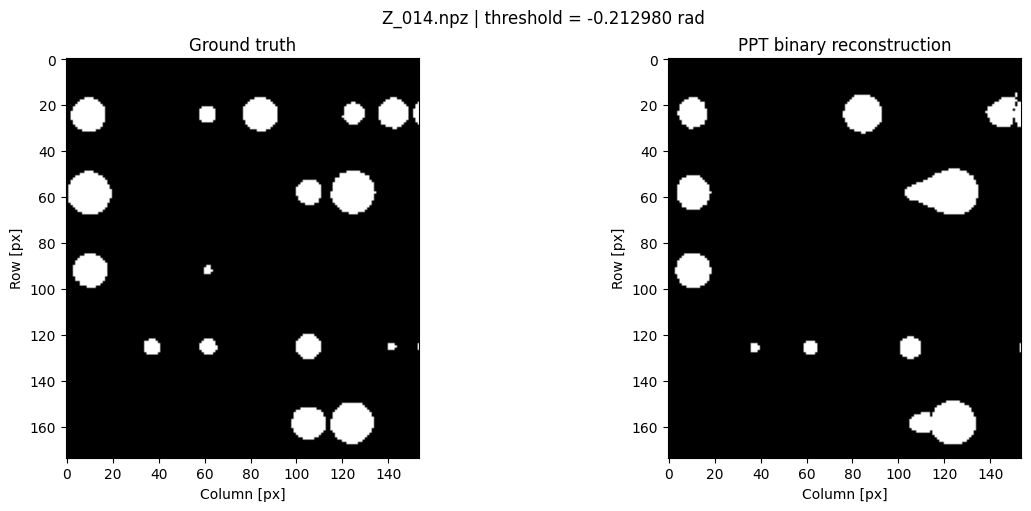

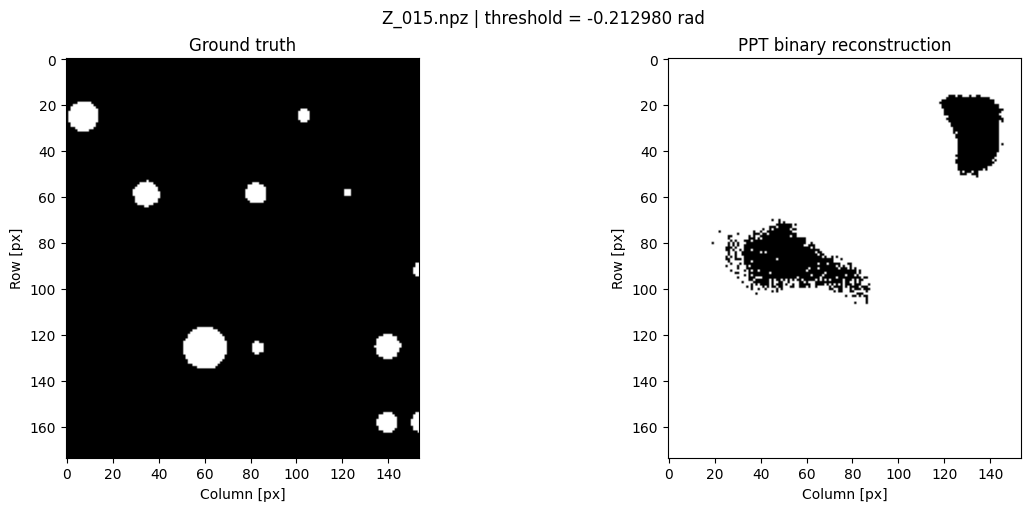

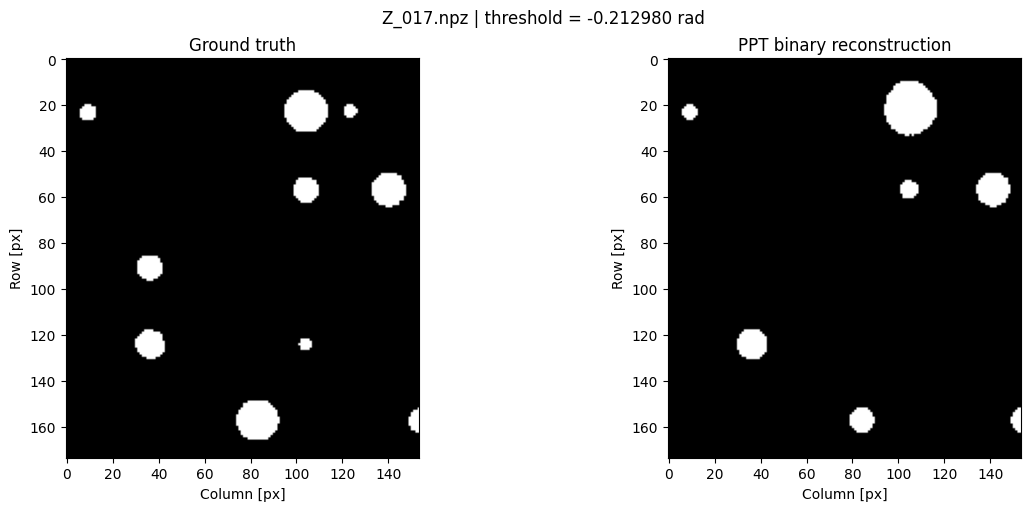

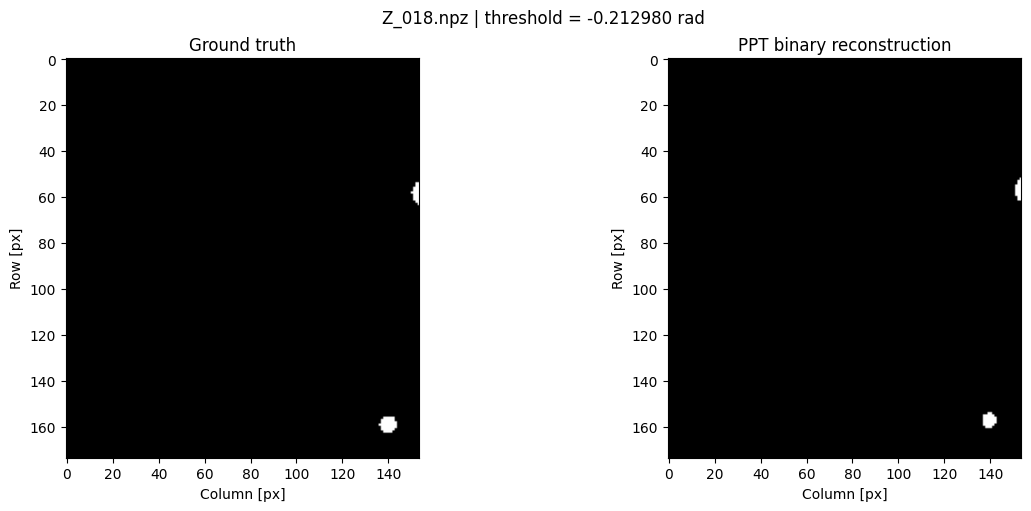

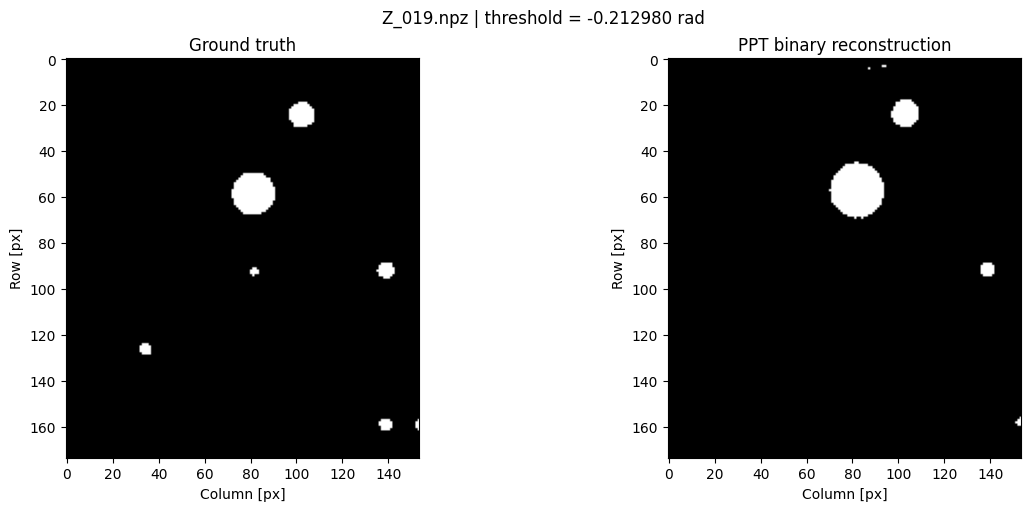

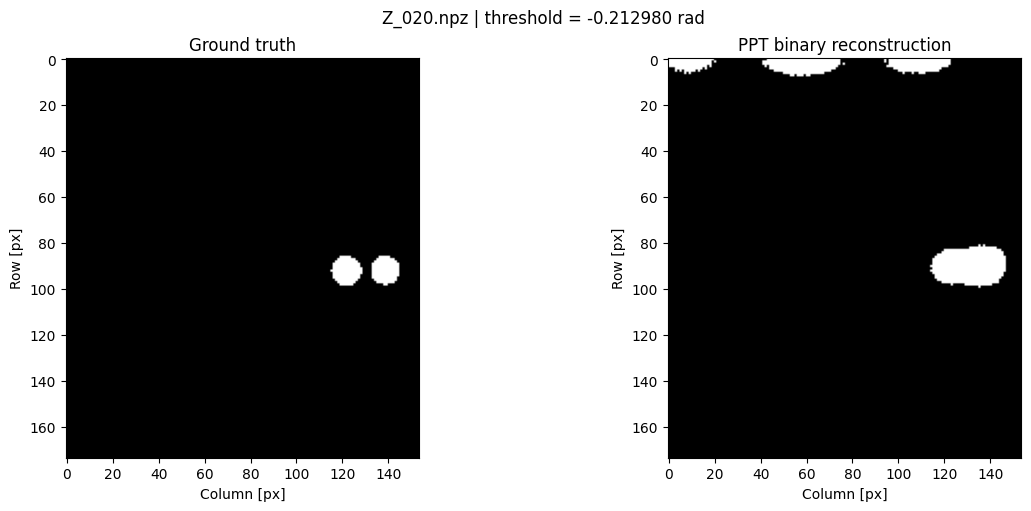

In [69]:
for filename, prediction in predicted_masks.items():
    with np.load(Path('/home/jaworskj/projects/thermal_B_scan/open_source_dataset/training') / filename) as sample:
        gt = sample["mask"] > 0

    fig, axes = plt.subplots(
        1, 2, figsize=(12, 5), constrained_layout=True
    )

    axes[0].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Ground truth")

    axes[1].imshow(prediction, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("PPT binary reconstruction")

    for ax in axes:
        ax.set_xlabel("Column [px]")
        ax.set_ylabel("Row [px]")

    fig.suptitle(f"{filename} | threshold = {best_threshold:.6f} rad")
    plt.show()

In [77]:
from pathlib import Path

import numpy as np
from scipy import ndimage as ndi
from tqdm.auto import tqdm
from Metrics_experimental_data import calculate_median_depth_errors


def optimize_inner_depth(
    train_path,
    sound_mean,
    thresholds=None,
):
    """
    Calibrate depth using GT-selected interior pixels.

    Uses:
        PPT(data, fps)
        calculate_median_depth_errors(...)

    Settings:
        fps = 10
        thickness = 5 mm
        erosion = 1 px
        inner_percent = 5

    Threshold search:
        Grid search, selecting lowest mean per-experiment MAE.
        RMSE breaks ties.

    At each threshold:
        Fit normalized depth = slope / sqrt(fb) + intercept.
        One calibration observation per defect, using its median
        interior feature. Every usable defect receives equal fit weight.

    Failed pixel estimates become zero during evaluation; they are
    not silently excluded from the reported errors.

    Returns:
        best_model, best_maps, overlays, history

    best_maps use original GT geometry: these are depth-evaluation maps.
    """
    if thresholds is None:
        thresholds = np.linspace(-0.05, -0.001, 1000)

    fps = 10
    thickness_mm = 5.0
    cached = {}
    overlays = {}

    for path in tqdm(
        sorted(Path(train_path).glob("*.npz")),
        desc="Extracting interior phases",
    ):
        with np.load(path) as sample:
            mask = np.asarray(sample["mask"], dtype=float)
            _, phase, frequencies = PPT(sample["data"], fps)

        frequencies = np.asarray(frequencies)
        keep = (frequencies > 0) & (frequencies < fps / 2)
        f = frequencies[keep]

        _, _, overlay = calculate_median_depth_errors(
            np.zeros_like(mask),
            mask,
            erosion_pixels=1,
            inner_percent=5,
        )

        selected = overlay == 2
        pixel_phase = np.asarray(phase)[keep][:, selected]

        contrast = np.angle(np.exp(
            1j * (
                pixel_phase
                - np.asarray(sound_mean)[keep, None]
            )
        ))

        # Same connected-component definition as your metric function.
        labels, count = ndi.label(
            mask > 0,
            structure=np.ones((3, 3), dtype=bool),
        )

        selected_labels = labels[selected]
        groups = []

        for label in range(1, count + 1):
            groups.append({
                "indices": np.flatnonzero(selected_labels == label),
                "true_depth": float(np.median(mask[labels == label])),
            })

        cached[path.name] = {
            "mask": mask,
            "selected": selected,
            "contrast": contrast,
            "frequencies": f,
            "groups": groups,
        }
        overlays[path.name] = overlay

    def extract_features(scene, threshold):
        """Return 1/sqrt(fb) for each selected pixel; NaN if unavailable."""
        c = scene["contrast"]
        f = scene["frequencies"]
        finite = np.isfinite(c)
        minimum_index = np.argmin(
            np.where(finite, c, np.inf), axis=0
        )
        columns = np.arange(c.shape[1])

        triggered = (
            (finite.sum(axis=0) >= 3)
            & (c[minimum_index, columns] < threshold)
        )

        crossings = (
            finite[:-1]
            & finite[1:]
            & (c[:-1] <= threshold)
            & (c[1:] > threshold)
            & (
                np.arange(len(f) - 1)[:, None]
                >= minimum_index[None, :]
            )
        )

        good = np.flatnonzero(triggered & crossings.any(axis=0))
        feature = np.full(c.shape[1], np.nan)

        if good.size:
            j = np.argmax(crossings[:, good], axis=0)
            fraction = (
                (threshold - c[j, good])
                / (c[j + 1, good] - c[j, good])
            )
            fb = f[j] + fraction * (f[j + 1] - f[j])
            feature[good] = 1 / np.sqrt(fb)

        return feature

    best_model = None
    best_maps = None
    best_key = None
    history = []

    progress = tqdm(thresholds, desc="Searching depth threshold")

    for threshold in progress:
        features = {}
        fit_x, fit_y = [], []
        missing_defects = 0

        for filename, scene in cached.items():
            feature = extract_features(scene, threshold)
            features[filename] = feature

            for group in scene["groups"]:
                values = feature[group["indices"]]
                values = values[np.isfinite(values)]

                if values.size:
                    fit_x.append(np.median(values))
                    fit_y.append(group["true_depth"])
                else:
                    missing_defects += 1

        # Cannot fit a depth calibration without distinct target depths.
        if len(fit_x) < 2 or len(np.unique(fit_y)) < 2:
            history.append({
                "threshold": float(threshold),
                "status": "insufficient_calibration_data",
            })
            continue

        slope, intercept = np.polyfit(fit_x, fit_y, 1)

        if slope <= 0:
            continue

        maps = {}
        per_experiment = []
        failed_pixels = 0
        total_pixels = 0

        for filename, scene in cached.items():
            feature = features[filename]
            estimates = slope * feature + intercept

            accepted = (
                np.isfinite(estimates)
                & (estimates > 0)
                & (estimates <= 1)
            )

            values = np.zeros(feature.size)
            values[accepted] = estimates[accepted]

            failed_pixels += int((~accepted).sum())
            total_pixels += feature.size

            prediction = np.zeros_like(scene["mask"])
            prediction[scene["selected"]] = values

            metrics, median_map, _ = calculate_median_depth_errors(
                prediction,
                scene["mask"],
                erosion_pixels=1,
                inner_percent=5,
            )

            maps[filename] = median_map
            per_experiment.append({
                "experiment": filename,
                "mae_mm": metrics["mae"] * thickness_mm,
                "medae_mm": metrics["medae"] * thickness_mm,
                "rmse_mm": metrics["rmse"] * thickness_mm,
            })

        result = {
            "status": "ok",
            "threshold": float(threshold),
            "slope": float(slope),
            "intercept": float(intercept),
            "erosion_pixels": 1,
            "inner_percent": 5,
            "mae_mm": float(np.mean([
                r["mae_mm"] for r in per_experiment
            ])),
            "medae_mm": float(np.mean([
                r["medae_mm"] for r in per_experiment
            ])),
            "rmse_mm": float(np.mean([
                r["rmse_mm"] for r in per_experiment
            ])),
            "defects_used_for_fit": len(fit_x),
            "defects_without_crossings": missing_defects,
            "failed_selected_pixels": failed_pixels,
            "total_selected_pixels": total_pixels,
            "per_experiment": per_experiment,
        }
        history.append(result)

        key = (result["mae_mm"], result["rmse_mm"])

        if best_key is None or key < best_key:
            best_key = key
            best_model = result
            best_maps = maps

        progress.set_postfix(
            MAE=f"{best_model['mae_mm']:.4f}",
            RMSE=f"{best_model['rmse_mm']:.4f}",
        )

    if best_model is not None:
        print(
            f"\nDepth threshold: {best_model['threshold']:.6f} rad\n"
            f"Normalized depth = {best_model['slope']:.6f}/sqrt(fb) "
            f"{best_model['intercept']:+.6f}\n"
            f"Mean MAE:   {best_model['mae_mm']:.4f} mm\n"
            f"Mean MedAE: {best_model['medae_mm']:.4f} mm\n"
            f"Mean RMSE:  {best_model['rmse_mm']:.4f} mm\n"
            f"Defects without crossings: "
            f"{best_model['defects_without_crossings']}\n"
            f"Failed selected pixels: "
            f"{best_model['failed_selected_pixels']}/"
            f"{best_model['total_selected_pixels']}"
        )

    return best_model, best_maps, overlays, history

In [78]:
depth_model, depth_maps, inner_overlays, depth_history = optimize_inner_depth(
    '/home/jaworskj/projects/thermal_B_scan/open_source_dataset/training',
    sound_phase["mean"],
)

Extracting interior phases:   0%|          | 0/26 [00:00<?, ?it/s]

/tmp/ipykernel_1964844/3861623930.py:64: UserWarning: Erosion removed 2 defect(s); used their deepest original pixels as fallback candidates.
  _, _, overlay = calculate_median_depth_errors(
/tmp/ipykernel_1964844/3861623930.py:64: UserWarning: Erosion removed 1 defect(s); used their deepest original pixels as fallback candidates.
  _, _, overlay = calculate_median_depth_errors(


Searching depth threshold:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_1964844/3861623930.py:208: UserWarning: Erosion removed 2 defect(s); used their deepest original pixels as fallback candidates.
  metrics, median_map, _ = calculate_median_depth_errors(
/tmp/ipykernel_1964844/3861623930.py:208: UserWarning: Erosion removed 1 defect(s); used their deepest original pixels as fallback candidates.
  metrics, median_map, _ = calculate_median_depth_errors(



Depth threshold: -0.048872 rad
Normalized depth = 0.053333/sqrt(fb) +0.054794
Mean MAE:   0.2065 mm
Mean MedAE: 0.1478 mm
Mean RMSE:  0.3536 mm
Defects without crossings: 33
Failed selected pixels: 61/944
